In [34]:
#4. tanh'ı parçala: exp, bölme ve pow operasyonlarını ekle, aynı gradient'leri aldığını göster. Sonra doğrula: aynı ifadeyi aynı değerlerle hem backward() ile hem geçen haftaki numerical derivative ile hem de PyTorch ile hesapla, üçünün eşleştiğini göster. (1:27:05 - 1:43:55)
# value + int, value * int, int * value problems solved with additions on task 3 core
import math
class Value:
    def __init__(self,data,_children=(),_op="", label=""):
        self.data = data
        self.grad = 0.0
        self._backward = lambda:None #leaf node
        self._prev = set(_children)
        self._op=_op
        self.label= label

    def __repr__(self):
        return f"Value(data={self.data})" 

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other) #solution for Value + int
        out = Value(self.data + other.data, (self, other), "+")

        def _backward():
            self.grad += 1 * out.grad #accumulates the grad
            other.grad += 1 * out.grad
        out._backward = _backward
        
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other) #Solution for Value * int
        out = Value(self.data * other.data, (self, other),"*")
            

        def _backward():
            self.grad += other.data * out.grad #accumulates the grad
            other.grad += self.data * out.grad
            
        out._backward = _backward
        return out

    def __pow__(self, other): 
        assert isinstance(other, (int,float))
        out = Value(self.data**other, (self,),f'**{other}')

        def _backward(): #x^n's derrivative
            self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward

        return out
    
    def __rmul__(self, other): #solution for int * value 
        return self * other

    def __truediv__(self,other): #self / other
        return self * other**-1

    def __neg__(self):
        return self * -1

    def __sub__(self,other):
        return self + (-other)
        
    def tanh(self):
        x=self.data
        t = (math.exp(2*x) - 1) / (math.exp (2*x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        
        return out

    def exp(self): #e^self.data
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')        

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        
        return out
        
    def backward(self):
        #sorting topo order
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        
        self.grad= 1.0  #first nodes grad = 1.0
        for node in reversed(topo):
            node._backward()


In [35]:
#Drawing computation graphs
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

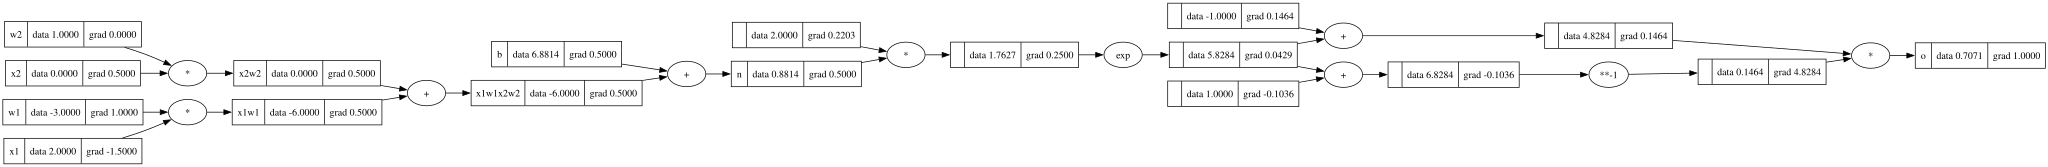

In [36]:
#same inputs and parameters with task 2 & 3 gives same output and gradients.
#inputs & parameters
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

b = Value(6.881373, label='b')
#weighted sums

x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2= x1w1 + x2w2; x1w1x2w2.label = 'x1w1x2w2'

n= x1w1x2w2 + b; n.label= 'n'

#new tanh
e = (2*n).exp() #e^2x
o =(e - 1) / (e + 1)

o.label= 'o'
o.backward()
draw_dot(o)

In [37]:
import torch #checking grads with pytorch

x1 = torch.Tensor([2.0]).double()                ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
b  = torch.Tensor([6.881373]).double() ; b.requires_grad  = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071064519863152
---
x2 0.500000465559325
w2 0.0
x1 -1.500001396677975
w1 1.00000093111865


In [38]:
#calculating gradients with numerical derivative formula
h=0.0001
i1=2.0
i2=0.0
wi1=-3.0
wi2=1.0
bias_term= 6.881373
base_o = math.tanh(((i1)*(wi1))+((i2*wi2)) + (bias_term))
grad_x1 = ((math.tanh(((i1+h)*(wi1))+((i2*wi2)) + (bias_term))) - (math.tanh(((i1)*(wi1))+((i2*wi2)) + (bias_term))))/h
grad_w1 = ((math.tanh(((i1)*(wi1+h))+((i2*wi2)) + (bias_term))) - (math.tanh(((i1)*(wi1))+((i2*wi2)) + (bias_term))))/h
grad_x2 = ((math.tanh(((i1)*(wi1))+(((i2+h)*(wi2))) + (bias_term))) - (math.tanh(((i1)*(wi1))+((i2*wi2)) + (bias_term))))/h
grad_w2 = ((math.tanh(((i1)*(wi1))+(((i2)*(wi2+h))) + (bias_term))) - (math.tanh(((i1)*(wi1))+((i2*wi2)) + (bias_term))))/h
print(base_o)

print('---')
print('x2', grad_x2)
print('w2', grad_w2)
print('x1', grad_x1)
print('w1', grad_w1)
    

0.7071064876766542
---
x2 0.4999650605641559
w2 0.0
x1 -1.5003194659413133
w1 0.9998594154259077


In [32]:
#all 3 matches.